In [13]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [17]:
# ---- Imports ----
import os
import wfdb
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


## Data Combine 

In [9]:
import pandas as pd
import numpy as np
import wfdb
import ast

def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path = '/Users/sumanthkamath/Documents/VS Code /BA878/Project/data/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv('data/ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv('data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass


In [10]:
Y.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]


In [15]:
print(f"Signal data shape: {X.shape}")
print(f"Signal length: {X.shape[1]} samples at {sampling_rate}Hz = {X.shape[1]/sampling_rate:.1f} seconds")
print(f"Number of leads: {X.shape[2]}")

Signal data shape: (21799, 1000, 12)
Signal length: 1000 samples at 100Hz = 10.0 seconds
Number of leads: 12


Signal characteristics:
- Shape: (21799, 1000, 12)
- Data type: float64
- Value range: [-20.032, 17.212]
- Mean: -0.001
- Standard deviation: 0.235


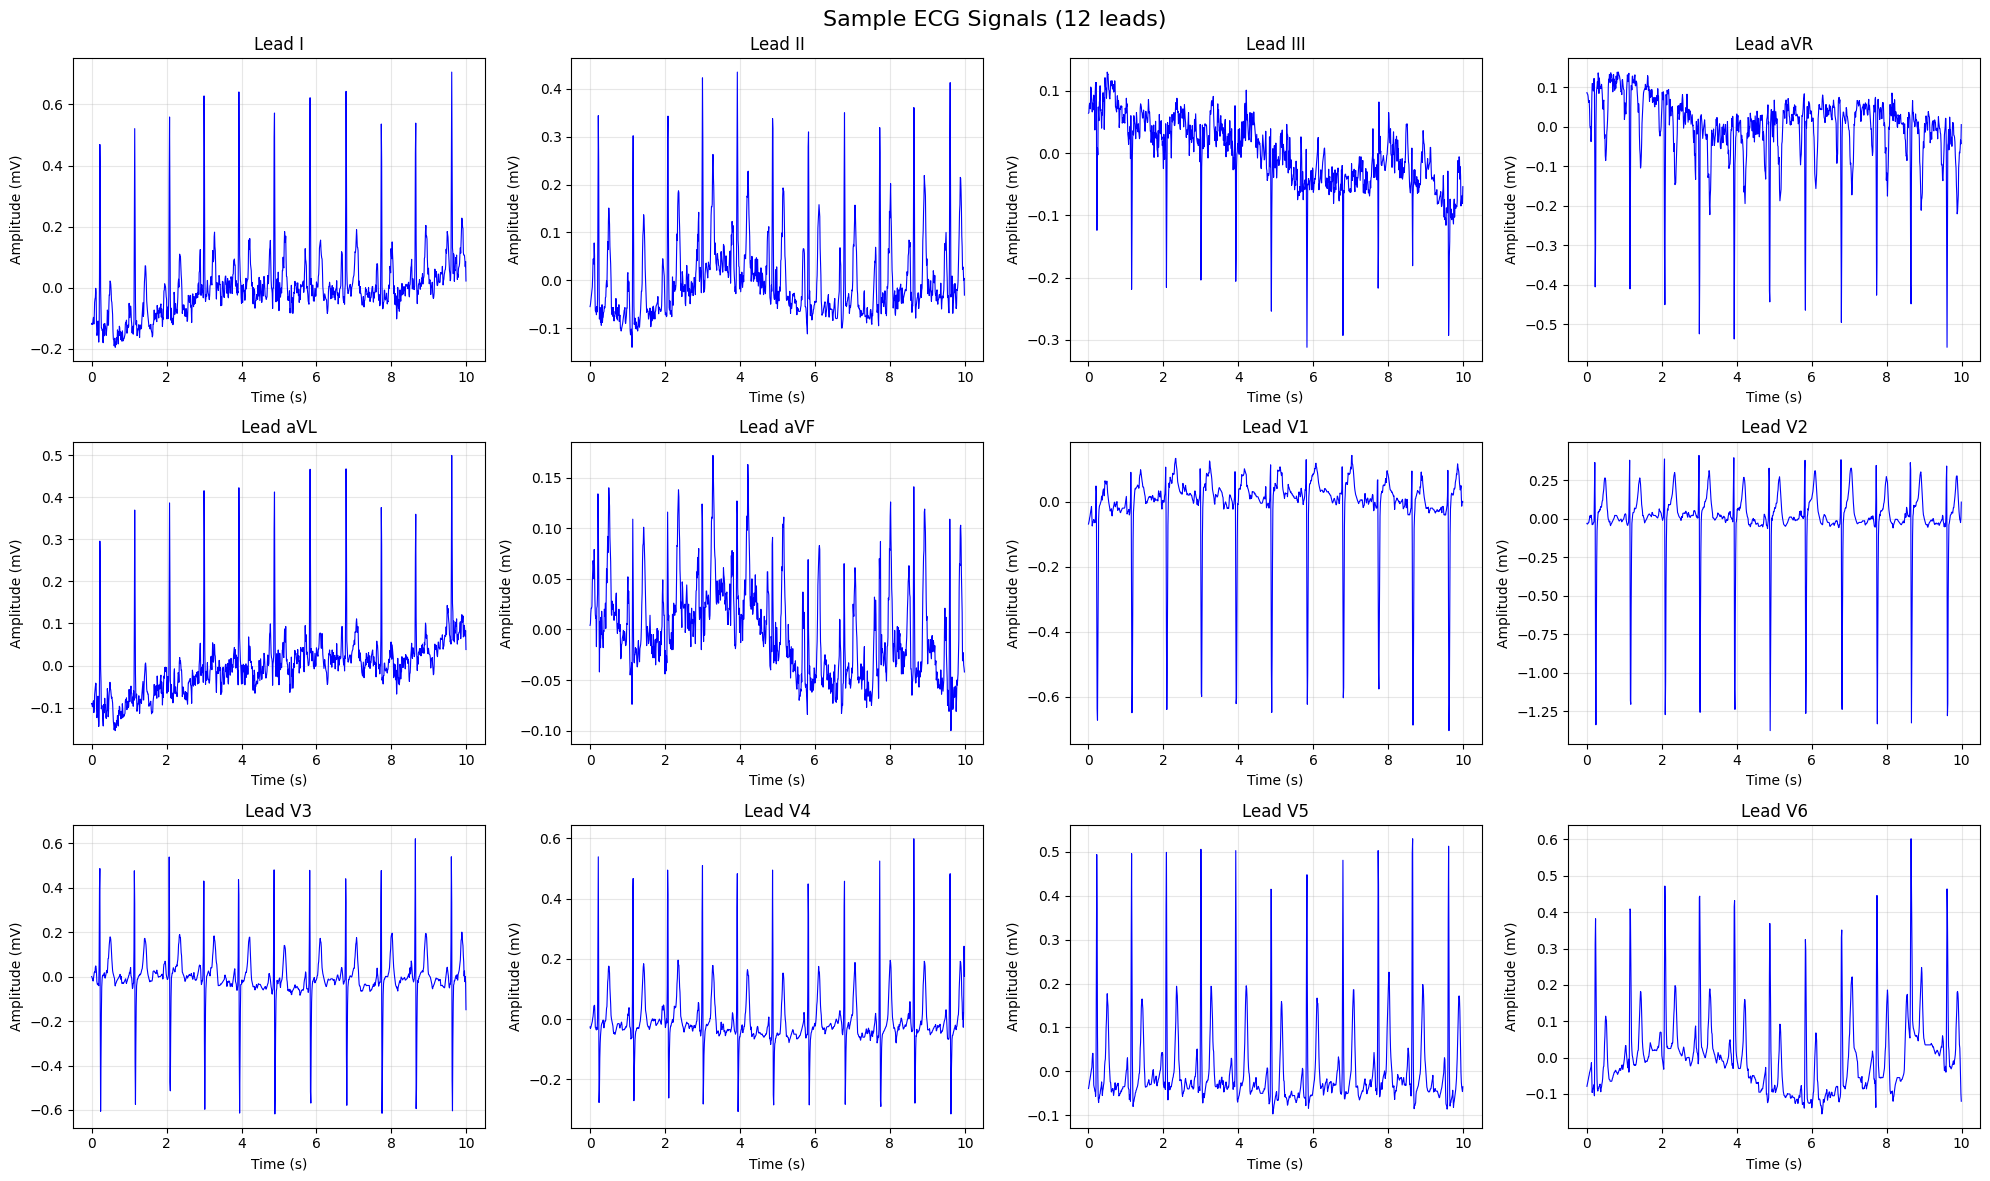

In [18]:
print(f"Signal characteristics:")
print(f"- Shape: {X.shape}")
print(f"- Data type: {X.dtype}")
print(f"- Value range: [{X.min():.3f}, {X.max():.3f}]")
print(f"- Mean: {X.mean():.3f}")
print(f"- Standard deviation: {X.std():.3f}")

# Plot sample ECG signals
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Sample ECG Signals (12 leads)', fontsize=16)

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Plot first ECG as example
sample_idx = 0
time_axis = np.arange(X.shape[1]) / sampling_rate

for lead in range(12):
    row, col = lead//4, lead%4
    axes[row, col].plot(time_axis, X[sample_idx, :, lead], 'b-', linewidth=0.8)
    axes[row, col].set_title(f'Lead {lead_names[lead]}')
    axes[row, col].set_xlabel('Time (s)')
    axes[row, col].set_ylabel('Amplitude (mV)')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
DATA_DIR = "data/records100/00000"   # relative to your current working directory
CSV_PATH = "data/ptbxl_database.csv"

print("Testing DATA_DIR:", os.path.abspath(DATA_DIR))
print("Exists:", os.path.exists(DATA_DIR))


Testing DATA_DIR: /Users/sumanthkamath/Documents/VS Code /BA878/Project/data/records100/00000
Exists: True


In [29]:
# ---- 2. Load a few ECG samples ----
records = [f.split('_')[0] for f in os.listdir(DATA_DIR) if f.endswith('.dat')]
# records = sorted(list(set(records)))[:10]  # just 10 for a quick demo
records = sorted(list(set(records)))  # use all ECGs in the folder


signals, labels = [], []

for rec in records:
    record_path = os.path.join(DATA_DIR, f"{rec}_lr")
    if not (os.path.exists(record_path + ".hea") and os.path.exists(record_path + ".dat")):
        print(f"⚠️ Skipping missing file: {record_path}")
        continue
    sig, _ = wfdb.rdsamp(record_path)
    signals.append(sig)
    labels.append(int(rec) % 5)  # dummy labels for demo

signals = np.stack(signals)
labels = np.array(labels)
print("✅ Data loaded:", signals.shape, "Labels:", np.unique(labels))


✅ Data loaded: (987, 1000, 12) Labels: [0 1 2 3 4]


In [30]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = ECGDataset(signals, labels)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [31]:
# ---- 4. Transformer Model ----
class ECGTransformer(nn.Module):
    def __init__(self, input_dim=12, embed_dim=64, num_heads=4, num_layers=2, num_classes=5):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=128, dropout=0.1
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        # x shape: (B, T, C)
        x = self.input_proj(x)
        x = x.permute(1, 0, 2)  # (T, B, E)
        x = self.encoder(x)
        x = x.permute(1, 2, 0)  # (B, E, T)
        return self.cls_head(x)

In [32]:
# ---- 5. Training Loop ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ECGTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Training on {device.upper()}...")

for epoch in range(15):
    total_loss, correct, total = 0, 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    print(f"Epoch {epoch+1}: Loss={total_loss/len(dataloader):.4f}, Acc={100*correct/total:.2f}%")

print("✅ Training complete!")

Training on CPU...
Epoch 1: Loss=1.6755, Acc=18.95%
Epoch 2: Loss=1.6351, Acc=19.35%
Epoch 3: Loss=1.6268, Acc=20.47%
Epoch 4: Loss=1.6230, Acc=19.35%
Epoch 5: Loss=1.6205, Acc=20.97%
Epoch 6: Loss=1.6167, Acc=20.36%
Epoch 7: Loss=1.6162, Acc=19.76%
Epoch 8: Loss=1.6125, Acc=19.96%
Epoch 9: Loss=1.6145, Acc=22.39%
Epoch 10: Loss=1.6118, Acc=21.18%
Epoch 11: Loss=1.6096, Acc=20.97%
Epoch 12: Loss=1.6089, Acc=20.06%
Epoch 13: Loss=1.6130, Acc=19.76%
Epoch 14: Loss=1.6084, Acc=20.67%
Epoch 15: Loss=1.6084, Acc=19.55%
✅ Training complete!


Epoch 1/15: Loss=1.6017, AUC=0.5650
Epoch 2/15: Loss=1.5925, AUC=0.5602
Epoch 3/15: Loss=1.5919, AUC=0.5581
Epoch 4/15: Loss=1.5959, AUC=0.5639
Epoch 5/15: Loss=1.5941, AUC=0.5608
Epoch 6/15: Loss=1.5925, AUC=0.5664
Epoch 7/15: Loss=1.5939, AUC=0.5716
Epoch 8/15: Loss=1.5934, AUC=0.5700
Epoch 9/15: Loss=1.5886, AUC=0.5720
Epoch 10/15: Loss=1.5934, AUC=0.5682
Epoch 11/15: Loss=1.5875, AUC=0.5687
Epoch 12/15: Loss=1.5869, AUC=0.5703
Epoch 13/15: Loss=1.5849, AUC=0.5748
Epoch 14/15: Loss=1.5835, AUC=0.5756
Epoch 15/15: Loss=1.5864, AUC=0.5783


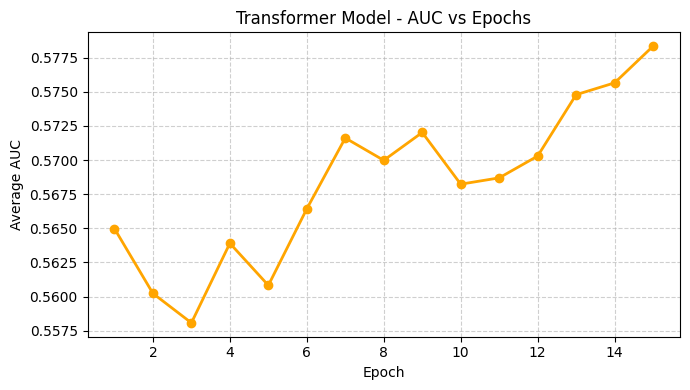

In [38]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

EPOCHS = 15
loss_history, auc_history = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    # ---- Training ----
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    # ---- Evaluation (AUC) ----
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            probs = torch.softmax(out, dim=1)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Compute average AUC across all classes
    n_classes = all_preds.shape[1]
    y_onehot = np.zeros((all_labels.size, n_classes))
    y_onehot[np.arange(all_labels.size), all_labels] = 1
    auc_score = roc_auc_score(y_onehot, all_preds, average="macro")
    auc_history.append(auc_score)

    print(f"Epoch {epoch+1}/{EPOCHS}: Loss={avg_loss:.4f}, AUC={auc_score:.4f}")

# ---- Plot AUC vs Epoch ----
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), auc_history, marker='o', color='orange', linewidth=2)
plt.title("Transformer Model - AUC vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average AUC")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

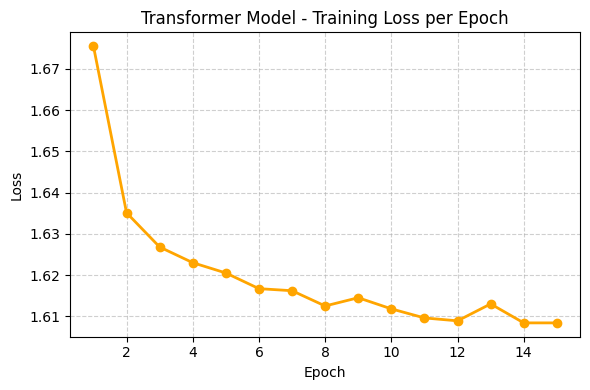

In [36]:
import matplotlib.pyplot as plt

loss_history = [
    1.6755, 1.6351, 1.6268, 1.6230, 1.6205, 
    1.6167, 1.6162, 1.6125, 1.6145, 1.6118, 
    1.6096, 1.6089, 1.6130, 1.6084, 1.6084
]

plt.figure(figsize=(6,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o', linewidth=2, color='orange')
plt.title("Transformer Model - Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()